## **0. Import libraries**

In [29]:
import torch
import random
from torch import nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [30]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

## **1. Prepare dataset**


In [31]:
batch_size = 512

train_dataset = FashionMNIST(root='data',
                             train=True,
                             transform=transforms.ToTensor(),
                             download=True)
test_dataset = FashionMNIST(root='data',
                            train=False,
                            transform=transforms.ToTensor(),
                            download=True)


# split val and train: random_split
train_ratio = 0.9
train_size = int(len(train_dataset) * train_ratio)
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# dataloader
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 54000
Validation size: 6000
Test size: 10000


## **2. Build MLP network**




In [32]:
class MLP(nn.Module):
    def __init__(self, input_dims, hidden_dims, output_dims):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(input_dims, hidden_dims)
        self.layer2 = nn.Linear(hidden_dims, hidden_dims)
        self.layer3 = nn.Linear(hidden_dims, hidden_dims)
        self.layer4 = nn.Linear(hidden_dims, hidden_dims)
        self.layer5 = nn.Linear(hidden_dims, hidden_dims)
        self.layer6 = nn.Linear(hidden_dims, hidden_dims)
        self.layer7 = nn.Linear(hidden_dims, hidden_dims)
        self.output = nn.Linear(hidden_dims, output_dims)

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = F.sigmoid(x)
        x = self.layer2(x)
        x = F.sigmoid(x)
        x = self.layer3(x)
        x = F.sigmoid(x)
        x = self.layer4(x)
        x = F.sigmoid(x)
        x = self.layer5(x)
        x = F.sigmoid(x)
        x = self.layer6(x)
        x = F.sigmoid(x)
        x = self.layer7(x)
        x = F.sigmoid(x)
        x = self.output(x)
        return x

In [33]:
# chia model 7 lớp thành 4 đầu vào: 2:2:2:1, thêm 1 lớp output.
# xây dựng các mô hình thành phần: MLP 2 lớp và MLP 1 lớp
class MLP_1Layer(nn.Module):
    def __init__(self, input_dims, output_dims):
        super(MLP_1Layer, self).__init__()
        self.flatten = nn.Flatten()
        self.layer = nn.Linear(input_dims, output_dims)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.layer(x)
        x = nn.Sigmoid()(x)
        return x

class MLP_2Layer(nn.Module):
    def __init__(self, input_dims, output_dims):
        super(MLP_2Layer, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(input_dims, output_dims)
        self.layer2 = nn.Linear(output_dims, output_dims)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Sigmoid()(x)
        return x

In [34]:
input_dims = len(train_subset.__getitem__(0)[0].flatten())
hidden_dims = 128
output_dims = len(train_dataset.classes)

# khởi tạo 4 mini-model, theo flow của baseline model.
first = MLP_2Layer(input_dims, hidden_dims)
second = MLP_2Layer(hidden_dims, hidden_dims)
third = MLP_2Layer(hidden_dims, hidden_dims)
fourth = MLP_1Layer(hidden_dims, hidden_dims)

In [35]:
class EarlyStopping:
    def __init__(self, max_count=2, epsilon=0.001):
        self.count = 0
        self.loss_prev = np.inf
        self.max_count = max_count
        self.epsilon = epsilon
    
    def earlystopping(self, loss_curr):
        if loss_curr < self.loss_prev:
            self.loss_prev = loss_curr
            self.count = 0
        elif loss_curr > (self.loss_prev + self.epsilon):
            self.count += 1
            if self.count >= self.max_count:
                return True
        return False

## **3. Training 01**

In [36]:
# train sub-model thứ nhất
model = nn.Sequential(
    first,
    nn.Linear(hidden_dims, output_dims)         # output layer
).to(device)

lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

In [37]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.3068, Train_Acc: 0.0945, Validation Loss: 1.3814, Val_Acc: 0.0935, counter = 0
EPOCH 2/100, Train_Loss: 2.3011, Train_Acc: 0.1317, Validation Loss: 1.3803, Val_Acc: 0.2570, counter = 0
EPOCH 3/100, Train_Loss: 2.2996, Train_Acc: 0.1516, Validation Loss: 1.3795, Val_Acc: 0.1225, counter = 0
EPOCH 4/100, Train_Loss: 2.2982, Train_Acc: 0.1752, Validation Loss: 1.3785, Val_Acc: 0.0937, counter = 0
EPOCH 5/100, Train_Loss: 2.2965, Train_Acc: 0.1587, Validation Loss: 1.3775, Val_Acc: 0.1342, counter = 0
EPOCH 6/100, Train_Loss: 2.2949, Train_Acc: 0.2157, Validation Loss: 1.3766, Val_Acc: 0.1725, counter = 0
EPOCH 7/100, Train_Loss: 2.2932, Train_Acc: 0.2255, Validation Loss: 1.3755, Val_Acc: 0.2297, counter = 0
EPOCH 8/100, Train_Loss: 2.2912, Train_Acc: 0.2768, Validation Loss: 1.3742, Val_Acc: 0.2217, counter = 0
EPOCH 9/100, Train_Loss: 2.2891, Train_Acc: 0.2401, Validation Loss: 1.3729, Val_Acc: 0.3068, counter = 0
EPOCH 10/100, Train_Loss: 2.2868, Train_Acc: 0

# **4. Training 02**

In [38]:
# đóng băng first để training 02
for param in first.parameters():
    param.requires_grad = False     # loại first khỏi quá trình tính toán cho step 2

model = nn.Sequential(
    first,
    second,
    nn.Linear(hidden_dims, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [39]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.3035, Train_Acc: 0.1050, Validation Loss: 1.3802, Val_Acc: 0.0937, counter = 0
EPOCH 2/100, Train_Loss: 2.2998, Train_Acc: 0.1234, Validation Loss: 1.3798, Val_Acc: 0.1913, counter = 0
EPOCH 3/100, Train_Loss: 2.2992, Train_Acc: 0.1199, Validation Loss: 1.3795, Val_Acc: 0.1987, counter = 0
EPOCH 4/100, Train_Loss: 2.2986, Train_Acc: 0.1539, Validation Loss: 1.3793, Val_Acc: 0.0895, counter = 0
EPOCH 5/100, Train_Loss: 2.2980, Train_Acc: 0.1604, Validation Loss: 1.3786, Val_Acc: 0.2253, counter = 0
EPOCH 6/100, Train_Loss: 2.2974, Train_Acc: 0.1785, Validation Loss: 1.3783, Val_Acc: 0.1985, counter = 0
EPOCH 7/100, Train_Loss: 2.2967, Train_Acc: 0.1725, Validation Loss: 1.3779, Val_Acc: 0.0918, counter = 0
EPOCH 8/100, Train_Loss: 2.2960, Train_Acc: 0.1983, Validation Loss: 1.3773, Val_Acc: 0.2005, counter = 0
EPOCH 9/100, Train_Loss: 2.2952, Train_Acc: 0.1751, Validation Loss: 1.3772, Val_Acc: 0.2567, counter = 0
EPOCH 10/100, Train_Loss: 2.2944, Train_Acc: 0

# **5. Training 03**

In [40]:
# mở khóa cả first và second để train cùng lúc
for param in first.parameters():
    param.requires_grad = True
for param in second.parameters():
    param.requires_grad = True

model = nn.Sequential(
    first,
    second,
    nn.Linear(128, 10)        # output layer
).to(device)

lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [43]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.1631, Train_Acc: 0.2739, Validation Loss: 1.2160, Val_Acc: 0.3955, counter = 0
EPOCH 2/100, Train_Loss: 1.9334, Train_Acc: 0.3947, Validation Loss: 1.1158, Val_Acc: 0.4187, counter = 0
EPOCH 3/100, Train_Loss: 1.7980, Train_Acc: 0.4314, Validation Loss: 1.0509, Val_Acc: 0.4287, counter = 0
EPOCH 4/100, Train_Loss: 1.7069, Train_Acc: 0.4490, Validation Loss: 1.0053, Val_Acc: 0.4253, counter = 0
EPOCH 5/100, Train_Loss: 1.6395, Train_Acc: 0.4594, Validation Loss: 0.9699, Val_Acc: 0.4732, counter = 0
EPOCH 6/100, Train_Loss: 1.5861, Train_Acc: 0.4848, Validation Loss: 0.9412, Val_Acc: 0.4788, counter = 0
EPOCH 7/100, Train_Loss: 1.5411, Train_Acc: 0.4894, Validation Loss: 0.9166, Val_Acc: 0.4990, counter = 0
EPOCH 8/100, Train_Loss: 1.5021, Train_Acc: 0.5118, Validation Loss: 0.8949, Val_Acc: 0.5200, counter = 0
EPOCH 9/100, Train_Loss: 1.4675, Train_Acc: 0.5222, Validation Loss: 0.8755, Val_Acc: 0.5265, counter = 0
EPOCH 10/100, Train_Loss: 1.4363, Train_Acc: 0

# **6. Training 04**

In [44]:
# khóa first và second, thêm third 
for param in first.parameters():
    param.requires_grad = False
for param in second.parameters():
    param.requires_grad = False

model = nn.Sequential(
    first,
    second,
    third,
    nn.Linear(128, 10)        # output layer
).to(device)

lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [45]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.3111, Train_Acc: 0.1030, Validation Loss: 1.3812, Val_Acc: 0.1020, counter = 0
EPOCH 2/100, Train_Loss: 2.3015, Train_Acc: 0.1116, Validation Loss: 1.3807, Val_Acc: 0.1142, counter = 0
EPOCH 3/100, Train_Loss: 2.3006, Train_Acc: 0.1101, Validation Loss: 1.3800, Val_Acc: 0.1395, counter = 0
EPOCH 4/100, Train_Loss: 2.2996, Train_Acc: 0.1128, Validation Loss: 1.3796, Val_Acc: 0.1912, counter = 0
EPOCH 5/100, Train_Loss: 2.2986, Train_Acc: 0.1428, Validation Loss: 1.3790, Val_Acc: 0.1003, counter = 0
EPOCH 6/100, Train_Loss: 2.2977, Train_Acc: 0.1209, Validation Loss: 1.3783, Val_Acc: 0.1890, counter = 0
EPOCH 7/100, Train_Loss: 2.2966, Train_Acc: 0.1666, Validation Loss: 1.3776, Val_Acc: 0.2172, counter = 0
EPOCH 8/100, Train_Loss: 2.2955, Train_Acc: 0.1760, Validation Loss: 1.3769, Val_Acc: 0.2015, counter = 0
EPOCH 9/100, Train_Loss: 2.2943, Train_Acc: 0.1929, Validation Loss: 1.3764, Val_Acc: 0.2510, counter = 0
EPOCH 10/100, Train_Loss: 2.2931, Train_Acc: 0

# **7. Training 05**

In [46]:
# mở khóa cả first và second, train cùng lúc với third
# khóa first và second, thêm third 
for param in first.parameters():
    param.requires_grad = True
for param in second.parameters():
    param.requires_grad = True

model = nn.Sequential(
    first,
    second,
    third,
    nn.Linear(128, 10)        # output layer
).to(device)

lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [47]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.1101, Train_Acc: 0.3650, Validation Loss: 1.1655, Val_Acc: 0.5075, counter = 0
EPOCH 2/100, Train_Loss: 1.8277, Train_Acc: 0.5170, Validation Loss: 1.0403, Val_Acc: 0.5458, counter = 0
EPOCH 3/100, Train_Loss: 1.6576, Train_Acc: 0.5318, Validation Loss: 0.9583, Val_Acc: 0.5450, counter = 0
EPOCH 4/100, Train_Loss: 1.5421, Train_Acc: 0.5421, Validation Loss: 0.9005, Val_Acc: 0.5472, counter = 0
EPOCH 5/100, Train_Loss: 1.4575, Train_Acc: 0.5482, Validation Loss: 0.8570, Val_Acc: 0.5497, counter = 0
EPOCH 6/100, Train_Loss: 1.3924, Train_Acc: 0.5533, Validation Loss: 0.8229, Val_Acc: 0.5513, counter = 0
EPOCH 7/100, Train_Loss: 1.3411, Train_Acc: 0.5580, Validation Loss: 0.7956, Val_Acc: 0.5635, counter = 0
EPOCH 8/100, Train_Loss: 1.2986, Train_Acc: 0.5672, Validation Loss: 0.7729, Val_Acc: 0.5578, counter = 0
EPOCH 9/100, Train_Loss: 1.2640, Train_Acc: 0.5649, Validation Loss: 0.7535, Val_Acc: 0.5702, counter = 0
EPOCH 10/100, Train_Loss: 1.2341, Train_Acc: 0

# **8. Training 06**

In [50]:
# khóa cả first, second và third. thêm fourth để train.
for param in first.parameters():
    param.requires_grad = False
for param in second.parameters():
    param.requires_grad = False
for param in third.parameters():
    param.requires_grad = False

model = nn.Sequential(
    first,
    second,
    third,
    fourth,
    nn.Linear(128, 10)      # output layer
).to(device)

lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [51]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.2935, Train_Acc: 0.1721, Validation Loss: 1.3645, Val_Acc: 0.4073, counter = 0
EPOCH 2/100, Train_Loss: 2.2588, Train_Acc: 0.4050, Validation Loss: 1.3454, Val_Acc: 0.4597, counter = 0
EPOCH 3/100, Train_Loss: 2.2250, Train_Acc: 0.5228, Validation Loss: 1.3238, Val_Acc: 0.5578, counter = 0
EPOCH 4/100, Train_Loss: 2.1858, Train_Acc: 0.5356, Validation Loss: 1.2988, Val_Acc: 0.6203, counter = 0
EPOCH 5/100, Train_Loss: 2.1396, Train_Acc: 0.5739, Validation Loss: 1.2688, Val_Acc: 0.6218, counter = 0
EPOCH 6/100, Train_Loss: 2.0850, Train_Acc: 0.5824, Validation Loss: 1.2337, Val_Acc: 0.6088, counter = 0
EPOCH 7/100, Train_Loss: 2.0223, Train_Acc: 0.5940, Validation Loss: 1.1938, Val_Acc: 0.5797, counter = 0
EPOCH 8/100, Train_Loss: 1.9531, Train_Acc: 0.5770, Validation Loss: 1.1513, Val_Acc: 0.6482, counter = 0
EPOCH 9/100, Train_Loss: 1.8800, Train_Acc: 0.6043, Validation Loss: 1.1068, Val_Acc: 0.5933, counter = 0
EPOCH 10/100, Train_Loss: 1.8060, Train_Acc: 0

# **9. Training 07**

In [52]:
# mở khóa tất cả 4 phần. Training lần cuối cùng. 
for param in first.parameters():
    param.requires_grad = True
for param in second.parameters():
    param.requires_grad = True
for param in third.parameters():
    param.requires_grad = True

model = nn.Sequential(
    first,
    second,
    third,
    fourth,
    nn.Linear(128, 10)      # output layer
).to(device)

lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [53]:
epochs = 100
train_loss_lst = []
train_acc_lst = []
val_loss_lst = []
val_acc_lst = []

stopper = EarlyStopping(max_count=3, epsilon=0.00001)
for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0

    model.train()
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, 1) == y_train).sum().item()
        count += len(y_train)

    train_loss /= len(train_loader)
    train_loss_lst.append(train_loss)
    train_acc /= count
    train_acc_lst.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs = model(X_val)
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, 1) == y_val).sum().item()
            count += len(y_val)

    val_loss /= len(test_loader)
    val_loss_lst.append(val_loss)
    val_acc /= count
    val_acc_lst.append(val_acc)
    # early stopping
    if stopper.earlystopping(val_loss):
        print(f"Early Stopping at epoch {epoch + 1}, minimum = {val_loss}")
        break

    print(f"EPOCH {epoch+1}/{epochs}, Train_Loss: {train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Val_Acc: {val_acc:.4f}, counter = {stopper.count}")


EPOCH 1/100, Train_Loss: 2.0630, Train_Acc: 0.3992, Validation Loss: 1.0957, Val_Acc: 0.5642, counter = 0
EPOCH 2/100, Train_Loss: 1.6867, Train_Acc: 0.5699, Validation Loss: 0.9443, Val_Acc: 0.5745, counter = 0
EPOCH 3/100, Train_Loss: 1.4907, Train_Acc: 0.5964, Validation Loss: 0.8547, Val_Acc: 0.6257, counter = 0
EPOCH 4/100, Train_Loss: 1.3679, Train_Acc: 0.6207, Validation Loss: 0.7952, Val_Acc: 0.6152, counter = 0
EPOCH 5/100, Train_Loss: 1.2838, Train_Acc: 0.6309, Validation Loss: 0.7530, Val_Acc: 0.6512, counter = 0
EPOCH 6/100, Train_Loss: 1.2220, Train_Acc: 0.6478, Validation Loss: 0.7216, Val_Acc: 0.6457, counter = 0
EPOCH 7/100, Train_Loss: 1.1748, Train_Acc: 0.6503, Validation Loss: 0.6965, Val_Acc: 0.6458, counter = 0
EPOCH 8/100, Train_Loss: 1.1370, Train_Acc: 0.6541, Validation Loss: 0.6767, Val_Acc: 0.6562, counter = 0
EPOCH 9/100, Train_Loss: 1.1062, Train_Acc: 0.6598, Validation Loss: 0.6600, Val_Acc: 0.6622, counter = 0
EPOCH 10/100, Train_Loss: 1.0807, Train_Acc: 0

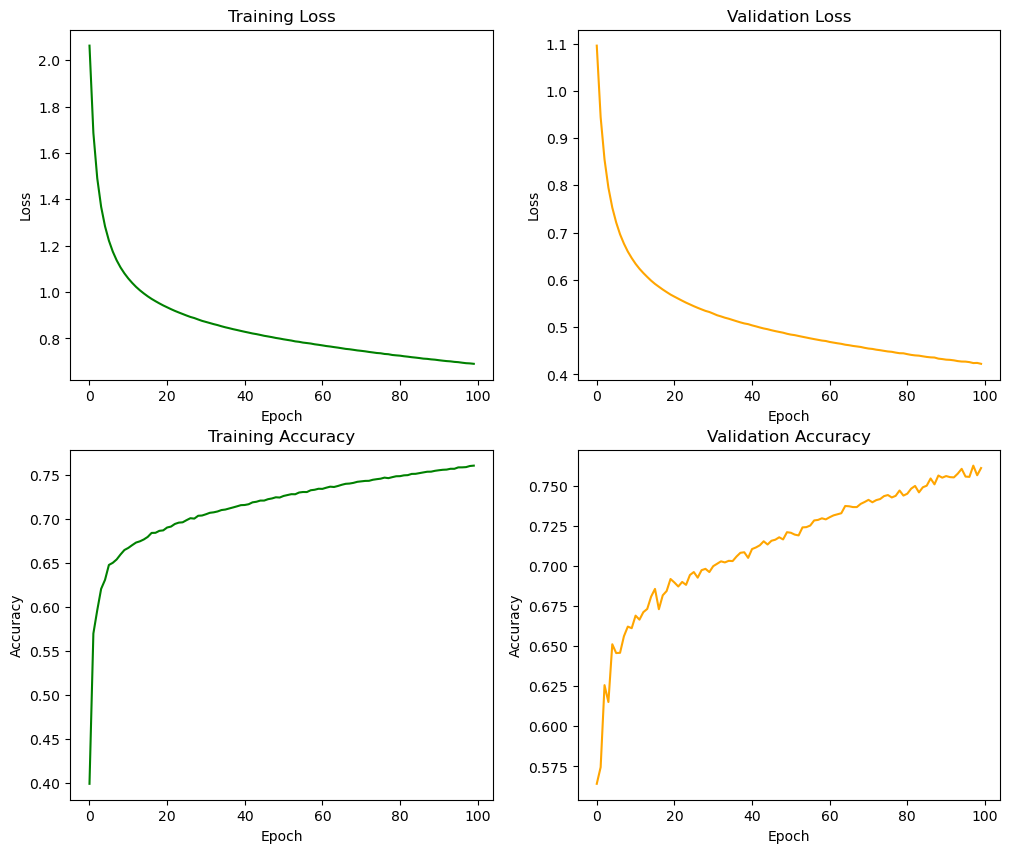

In [54]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_loss_lst, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_loss_lst, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_acc_lst, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_acc_lst, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

## **4. Evaluation**

In [55]:
val_target = []
val_predict = []

model.eval()
with torch.no_grad():
    for X_val, y_val in val_loader:
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        outputs = model(X_val)

        val_predict.append(outputs.cpu())
        val_target.append(y_val.cpu())

    val_predict = torch.cat(val_predict)
    val_target = torch.cat(val_target)
    val_acc = (torch.argmax(val_predict, 1) == val_target).sum().item() / len(val_target)

    print('Evaluation on val set:')
    print(f'Accuracy: {val_acc}')

Evaluation on val set:
Accuracy: 0.761
